In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier

In [2]:
training_data = [[1, 2], [2, 3], [3, 4], [6, 7]]
labels = ["A", "A", "B", "B"]
query_point = [5, 4]

## Simple Implementation

In [3]:
def _get_majority_vote(neighbors):
    if not neighbors:
        raise ValueError("Neighbours list cannot be empty.")

    vote_count = {}
    min_distance_per_label = {}

    for neighbour in neighbors:
        label = neighbour["label"]
        distance = neighbour["distance"]

        vote_count[label] = vote_count.get(label, 0) + 1
        min_distance_per_label[label] = min(
            distance, min_distance_per_label.get(label, float("inf"))
        )

    # More efficient than sorting full list
    best_label = None
    best_vote = -1
    best_distance = float("inf")

    for label in vote_count:
        votes = vote_count[label]
        dist = min_distance_per_label[label]

        if (votes > best_vote) or (votes == best_vote and dist < best_distance):
            best_label = label
            best_vote = votes
            best_distance = dist

    return best_label

In [4]:
def knn_predict(training_data, labels, query_point, k):
    # --- Input validation ---
    if len(training_data) == 0 or len(labels) == 0:
        raise ValueError("Training data and labels must not be empty.")

    if len(training_data) != len(labels):
        raise ValueError("Training data and labels must have the same length.")

    if not isinstance(k, int) or k <= 0:
        raise ValueError("k must be a positive integer.")

    if k > len(training_data):
        raise ValueError("k cannot be larger than the number of training samples.")

    # Convert to NumPy for efficiency
    X = np.array(training_data)
    q = np.array(query_point)

    # Vectorized distance computation
    distances = np.linalg.norm(X - q, axis=1)

    # Get indices of k smallest distances
    nearest_idx = np.argsort(distances)[:k]

    neighbours = [{"distance": distances[i], "label": labels[i]} for i in nearest_idx]

    return _get_majority_vote(neighbours)

In [5]:
prediction = knn_predict(training_data, labels, query_point, k=3)
print("Predicted label:", prediction)

Predicted label: B


## Numpy  Implementation

In [6]:
def knn_predict(X, y, query_point, k):
    X = np.array(X)
    y = np.array(y)
    q = np.array(query_point)

    # Step 1: Compute distances
    distances = np.sqrt(np.sum((X - q) ** 2, axis=1))

    # Step 2: Get k nearest
    idx = np.argsort(distances)[:k]
    nearest_labels = y[idx]
    nearest_distances = distances[idx]

    # Step 3: Voting
    unique_labels = np.unique(nearest_labels)

    best_label = None
    best_vote = -1
    best_distance = float("inf")

    for label in unique_labels:
        mask = nearest_labels == label
        votes = np.sum(mask)
        min_dist = np.min(nearest_distances[mask])

        if (votes > best_vote) or (votes == best_vote and min_dist < best_distance):
            best_label = label
            best_vote = votes
            best_distance = min_dist

    # Return extra values for plotting
    return best_label, idx, distances

In [7]:
prediction = knn_predict(training_data, labels, query_point, k=3)
print("Predicted label:", prediction)

Predicted label: (np.str_('B'), array([2, 1, 3]), array([4.47213595, 3.16227766, 2.        , 3.16227766]))


In [8]:
def plot_knn(X, y, query_point, k):
    X = np.array(X)
    y = np.array(y)
    q = np.array(query_point)

    # Use knn_predict
    prediction, neighbor_idx, distances = knn_predict(X, y, query_point, k)

    plt.figure(figsize=(8, 6))

    # Plot each class separately
    for label in np.unique(y):
        points = X[y == label]

        plt.scatter(points[:, 0], points[:, 1], s=100, label=f"Class {label}")

    # Plot nearest neighbors
    neighbors = X[neighbor_idx]

    plt.scatter(
        neighbors[:, 0],
        neighbors[:, 1],
        s=250,
        facecolors="none",
        edgecolors="black",
        linewidths=2,
        label=f"{k} Nearest Neighbors",
    )

    # Plot query point
    plt.scatter(
        q[0], q[1], color="red", marker="X", s=200, label=f"Query → {prediction}"
    )

    # Draw lines to neighbors
    for point in neighbors:
        plt.plot([q[0], point[0]], [q[1], point[1]], linestyle="--")

    plt.title(f"KNN Visualization (k={k})")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.legend()
    plt.grid(True)
    plt.show()

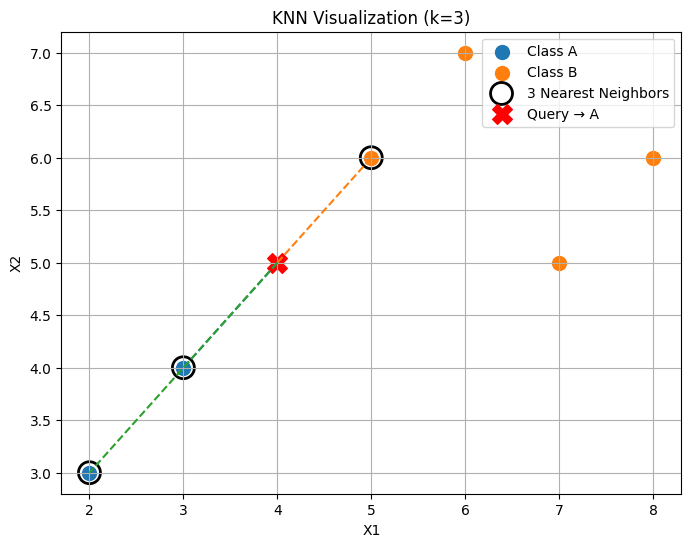

In [9]:
X = [[2, 3], [3, 4], [5, 6], [6, 7], [7, 5], [8, 6]]

y = ["A", "A", "B", "B", "B", "B"]

query_point = [4, 5]

plot_knn(X, y, query_point, k=3)

##  Sklearn Implementation

In [10]:
def knn(n_neighbours: int, metric: str = "euclidean"):
    model = KNeighborsClassifier(n_neighbors=n_neighbours, metric=metric)
    return model

In [11]:
model = knn(n_neighbours=3)

# Train
model.fit(training_data, labels)

# Predict
prediction = model.predict(np.array([query_point]))
print("Predicted label:", prediction[0])

Predicted label: B
